# 03. 루틴형 고객 식별 — Routine Score 기반 오퍼 비의존 고객 분류

**핵심 질문:**  
> 오퍼 없이도 구매하는 고객은 누구인가?

**데이터:** `prep_master_table.csv` · `timeline.csv`  
**발견:** 상위 30%는 오퍼 수신 여부와 무관하게 일정한 구매 패턴 유지

**Routine Score 구성:**

| 지표 | 가중치 | 방향 | 설명 |
|------|--------|------|------|
| tx_active_days | 45% | ↑ 높을수록 | 총 방문 일수 |
| avg_gap_days | 35% | ↓ 낮을수록 | 평균 방문 간격 |
| tx_per_offer | 20% | ↑ 높을수록 | 오퍼 없는 거래 비율 |

→ 각 지표 z-score 표준화 후 가중 합산  
→ 상위 30% = 루틴형 고객

---

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from matplotlib import rc

plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# 전처리 완료된 마스터 테이블 로드
# 01_data_preparation.ipynb 실행 후 생성된 파일 사용
mt = pd.read_csv("../data/processed/prep_master_table.csv")

mt.head()

,person,event,time,amount,offer_id,reward,gender,age,became_member_on,income,...,reward_offer,channels,difficulty,duration,offer_type,email,mobile,social,web,duration_hr
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,F,75,2017-05-09,100000.0,...,5.0,"['web', 'email', 'mobile']",5.0,7.0,bogo,1.0,1.0,0.0,1.0,168.0
1,e2127556f4f64592b11af22de27a7932,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,M,68,2018-04-26,70000.0,...,2.0,"['web', 'email', 'mobile']",10.0,7.0,discount,1.0,1.0,0.0,1.0,168.0
2,389bc3fa690240e798340f5a15918d5c,offer received,0,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN,M,65,2018-02-09,53000.0,...,5.0,"['web', 'email', 'mobile', 'social']",5.0,5.0,bogo,1.0,1.0,1.0,1.0,120.0
3,2eeac8d8feae4a8cad5a6af0499a211d,offer received,0,NaN,3f207df678b143eea3cee63160fa8bed,NaN,M,58,2017-11-11,51000.0,...,0.0,"['web', 'email', 'mobile']",0.0,4.0,informational,1.0,1.0,0.0,1.0,96.0
4,aa4862eba776480b8bb9c68455b8c2e1,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,F,61,2017-09-11,57000.0,...,5.0,"['web', 'email']",20.0,10.0,discount,1.0,0.0,0.0,1.0,240.0


## 1. 루틴형 고객 정의 기준

**기존 접근:** 오퍼 완료 횟수, 소득·연령 세그먼트  
→ "오퍼에 반응한 고객"만 파악 가능

**새로운 접근:** 방문 패턴의 규칙성  
→ "오퍼 없이도 오는 고객"을 행동 지표로 직접 측정

| 지표 | 기준값 | 의미 |
|------|--------|------|
| tx_active_days (평균) | 7.28일 | 이보다 방문 많으면 단골 가능성 |
| avg_gap_days (평균) | 4.26일 | 이보다 간격 짧으면 자주 오는 고객 |

---

## 2. 타임라인 데이터셋 구축

offer received 기준으로 viewed / completed / transaction을 시간순으로 연결  
→ 각 오퍼 인스턴스 내 고객 행동 전체 추적 가능

---

In [3]:
# 타임라인 구성 전처리 — 데이터 타입 정규화

df21 = mt.copy()

# 데이터 타입 정리
df21['time'] = pd.to_numeric(df21['time'], errors="coerce")
df21['amount'] = pd.to_numeric(df21['amount'], errors="coerce")

In [4]:
# offer received 이벤트 추출

recv = (
    df21[df21['event'].eq('offer received')]
    .loc[:, [
        "person", "offer_id", "event", "time",
        "duration_hr", "offer_type", "reward", "difficulty", "channels",
        "email", "mobile", "social", "web",
        "gender_g", "age_g", "income_g", "membership_g", "membership_years"
    ]]
    .dropna(subset=["person","offer_id","time"])
    .rename(columns={"time": "received_time"})
    .sort_values(["person","offer_id","received_time"])
    .reset_index(drop=True)
)

recv['offer_instance'] = recv.groupby(['person','offer_id']).cumcount() + 1
recv['expiry_time'] = recv['received_time'] + recv['duration_hr']

display(recv.head())

,person,offer_id,event,received_time,duration_hr,offer_type,reward,difficulty,channels,email,mobile,social,web,gender_g,age_g,income_g,membership_g,membership_years,offer_instance,expiry_time
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,offer received,576,168.0,discount,NaN,10.0,"['web', 'email', 'mobile']",1.0,1.0,0.0,1.0,M,25-34,Mid-High,1~3yr,1.262149,1,744.0
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,offer received,336,96.0,informational,NaN,0.0,"['web', 'email', 'mobile']",1.0,1.0,0.0,1.0,M,25-34,Mid-High,1~3yr,1.262149,1,432.0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,offer received,168,72.0,informational,NaN,0.0,"['email', 'mobile', 'social']",1.0,1.0,1.0,0.0,M,25-34,Mid-High,1~3yr,1.262149,1,240.0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,offer received,408,120.0,bogo,NaN,5.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,M,25-34,Mid-High,1~3yr,1.262149,1,528.0
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,offer received,504,240.0,discount,NaN,10.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,M,25-34,Mid-High,1~3yr,1.262149,1,744.0


In [5]:
# viewed / completed 이벤트를 received에 매칭 (벡터화)

def match_event_to_received_loop(event_df, recv_df,
                                 event_time_col="event_time",
                                 keep_recv_event=True):
    recv_key = recv_df.copy()
    if keep_recv_event and "event" in recv_key.columns:
        recv_key = recv_key.rename(columns={"event": "recv_event"})
    elif "event" in recv_key.columns:
        recv_key = recv_key.drop(columns=["event"])

    ev = event_df.copy()
    ev["t"] = pd.to_numeric(ev[event_time_col], errors="coerce")
    recv_key["t"] = pd.to_numeric(recv_key["received_time"], errors="coerce")

    # merge_asof requires sort by 'on' column (t) globally
    ev = ev.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    rk = recv_key.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

    if ev.empty or rk.empty:
        return pd.DataFrame()

    matched = pd.merge_asof(
        ev,
        rk,
        on="t",
        by=["person","offer_id"],
        direction="backward",
        allow_exact_matches=True,
        suffixes=("", "_recv")
    )
    matched = matched.drop(columns=["t"], errors="ignore")
    return matched

In [6]:
recv_tl = recv.copy()
recv_tl["event_time"] = recv_tl["received_time"]
recv_tl["event"] = "offer received"   # 혹시 표준화 필요하면

In [7]:
# viewed 이벤트 → 타임라인
view = (
    df21[df21["event"].eq("offer viewed")]
    .loc[:, ["person","offer_id","event","time"]]
    .dropna(subset=["person","offer_id","time"])
    .rename(columns={"time":"event_time"})
    .sort_values(["person","offer_id","event_time"])
    .reset_index(drop=True)
)

view_m = match_event_to_received_loop(view, recv, event_time_col="event_time", keep_recv_event=True)

view_tl = view_m[
    (view_m["event_time"] >= view_m["received_time"]) &
    (view_m["event_time"] <= view_m["expiry_time"])
].copy()

view_tl = view_tl[[
    "person","offer_id","offer_instance",
    "event","event_time",
    "received_time","expiry_time",
    "offer_type","difficulty","duration_hr",
    "gender_g","age_g","income_g","membership_g","membership_years"
]]

In [8]:
# completed 이벤트 → 타임라인
comp_ev = (
    df21[df21["event"].eq("offer completed")]
    .loc[:, ["person","offer_id","event","time"]]
    .dropna(subset=["person","offer_id","time"])
    .rename(columns={"time":"event_time"})
    .sort_values(["person","offer_id","event_time"])
    .reset_index(drop=True)
)

comp_m = match_event_to_received_loop(comp_ev, recv, event_time_col="event_time", keep_recv_event=True)

comp_tl = comp_m[
    (comp_m["event_time"] >= comp_m["received_time"]) &
    (comp_m["event_time"] <= comp_m["expiry_time"])
].copy()

comp_tl = comp_tl[[
    "person","offer_id","offer_instance",
    "event","event_time",
    "received_time","expiry_time",
    "offer_type","difficulty","duration_hr",
    "gender_g","age_g","income_g","membership_g","membership_years"
]]

In [9]:
# transaction 이벤트 → 타임라인
tx_tl = (
    df21[df21["event"].eq("transaction")]
    .loc[:, ["person","event","time","amount",
             "gender_g","age_g","income_g","membership_g","membership_years"]]
    .dropna(subset=["person","time"])
    .rename(columns={"time":"event_time"})
    .sort_values(["person","event_time"])
    .reset_index(drop=True)
)

for c in ["offer_id","offer_instance","received_time","expiry_time",
          "offer_type","difficulty","duration_hr"]:
    if c not in tx_tl.columns:
        tx_tl[c] = np.nan

In [10]:
# 타임라인 통합
base_cols = [
    "person","event_time","event",
    "offer_id","offer_instance","received_time","expiry_time",
    "offer_type","difficulty","duration_hr",
    "gender_g","age_g","income_g","membership_g","membership_years",
    "amount"
]

def align_cols(df, cols):
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = np.nan
    return out[cols]

timeline = pd.concat(
    [
        align_cols(recv_tl, base_cols),
        align_cols(view_tl, base_cols),
        align_cols(comp_tl, base_cols),
        align_cols(tx_tl, base_cols),
    ],
    ignore_index=True,
    sort=False
).sort_values(["person","event_time","event"]).reset_index(drop=True)

## 3. 방문 빈도 및 방문 주기 분석

고객별 방문 패턴 지표 3개 산출:

- **tx_active_days**: 총 방문 일수
- **avg_gap_days**: 평균 방문 간격
- **cv_gap_days**: 방문 간격의 변동계수 (낮을수록 규칙적)

---

In [11]:
# 고객별 방문 일수 계산

tl = timeline.copy()

# 1) event_time이 hour 기준이라고 가정
tl["day"] = (tl["event_time"] // 24).astype("Int64")

# 2) transaction만 필터
tx = tl[tl["event"].eq("transaction")].copy()

# 3) 고객별 방문일수
visit_days = (
    tx.groupby("person")["day"]
      .nunique()
      .rename("tx_active_days")
      .reset_index()
)

visit_days.head()

,person,tx_active_days
0,0009655768c64bdeb2e877511632db8f,8
1,0011e0d4e6b944f998e987f904e8c1e5,5
2,0020c2b971eb4e9188eac86d93036a77,6
3,0020ccbbb6d84e358d3414a3ff76cffd,11
4,003d66b6608740288d6cc97a6903f4f0,14


In [12]:
# 고객별 방문 간격 계산

# 고객별 방문일 리스트(중복 제거) 만들고 정렬
tx_days = (
    tx[["person","day"]]
    .drop_duplicates()
    .sort_values(["person","day"])
)

# 같은 고객 내에서 이전 방문일과의 차이(간격)
tx_days["gap_days"] = tx_days.groupby("person")["day"].diff()
tx_days.head(10)

,person,day,gap_days
2,0009655768c64bdeb2e877511632db8f,9,<NA>
7,0009655768c64bdeb2e877511632db8f,17,8
11,0009655768c64bdeb2e877511632db8f,22,5
13,0009655768c64bdeb2e877511632db8f,23,1
16,0009655768c64bdeb2e877511632db8f,24,1
17,0009655768c64bdeb2e877511632db8f,27,3
18,0009655768c64bdeb2e877511632db8f,28,1
19,0009655768c64bdeb2e877511632db8f,29,1
22,0011e0d4e6b944f998e987f904e8c1e5,5,<NA>
26,0011e0d4e6b944f998e987f904e8c1e5,10,5


In [13]:
# 실거래(transaction)만 추출
tx = (
    timeline[
        (timeline["event"] == "transaction") &
        (timeline["amount"].notna()) &
        (timeline["amount"] > 0)
    ]
    .loc[:, ["person", "event_time", "amount"]]
    .copy()
)

# person별 첫 거래일 / 마지막 거래일 계산
tx_days = (
    tx.groupby("person", as_index=False)
      .agg(
          first_tx_time=("event_time", "min"),
          last_tx_time=("event_time", "max"),
          n_tx=("event_time", "count")
      )
)

# 첫 거래일 = 마지막 거래일인 person 추출
same_day_customers_df = tx_days[
    tx_days["first_tx_time"] == tx_days["last_tx_time"]
].copy()

display(same_day_customers_df)

,person,first_tx_time,last_tx_time,n_tx
45,00ee2ca6421c4af0aeca60a1b3e00f6c,708,708,1
129,0252aa6f0dee4585ba886945c60f48f5,282,282,1
131,026876bc8c6a4e0c8e330342c92cc844,366,366,1
151,02db8af535e54416a01aff51836d166f,648,648,1
179,034dcdec0a0547a19d77dcf2bc8ecc48,348,348,1
...,...,...,...,...
14321,fcd0080e7fa846abbb637131d0c466e3,600,600,1
14334,fd13cda6e91f454f87eab139205e45cd,702,702,1
14391,fe285265878948309a32b47b216d2a65,714,714,1
14428,fef4f14201c44ddd915f504b7d88bf08,714,714,1


## 4. 시각화 — 세그먼트별 방문 패턴 분포

view/complete 비율과 방문일수×방문주기 버블차트로 루틴형 고객군 시각적 확인

---

In [14]:
tl = timeline.copy()

# 1) event_time이 hour 기준이라고 가정
tl["day"] = (tl["event_time"] // 24).astype("Int64")

# 2) transaction만 필터
tx = tl[tl["event"].eq("transaction")].copy()

# 3) 고객별 transaction 발생 '일(day)'의 고유 개수 = 방문일수
visit_days = (
    tx.groupby("person")["day"]
      .nunique()
      .rename("tx_active_days")
      .reset_index()
)

# 고객별 방문일 리스트(중복 제거) 만들고 정렬
tx_days = (
    tx[["person","day"]]
    .drop_duplicates()
    .sort_values(["person","day"])
)

# 같은 고객 내에서 이전 방문일과의 차이(간격)
tx_days["gap_days"] = tx_days.groupby("person")["day"].diff()
tx_days.head(10)

,person,day,gap_days
2,0009655768c64bdeb2e877511632db8f,9,<NA>
7,0009655768c64bdeb2e877511632db8f,17,8
11,0009655768c64bdeb2e877511632db8f,22,5
13,0009655768c64bdeb2e877511632db8f,23,1
16,0009655768c64bdeb2e877511632db8f,24,1
17,0009655768c64bdeb2e877511632db8f,27,3
18,0009655768c64bdeb2e877511632db8f,28,1
19,0009655768c64bdeb2e877511632db8f,29,1
22,0011e0d4e6b944f998e987f904e8c1e5,5,<NA>
26,0011e0d4e6b944f998e987f904e8c1e5,10,5


In [15]:
# 고객별 방문주기 요약

visit_cycle = (
    tx_days.groupby("person")["gap_days"]
          .agg(
              avg_gap_days="mean",
              median_gap_days="median",
              min_gap_days="min",
              max_gap_days="max",
              std_gap_days="std"
          )
          .reset_index()
)

display(visit_cycle.head())
display(visit_cycle.describe())
print('[고객 방문 간격 중앙값의 평균] :', round(visit_cycle['median_gap_days'].mean(),2), '일')

,person,avg_gap_days,median_gap_days,min_gap_days,max_gap_days,std_gap_days
0,0009655768c64bdeb2e877511632db8f,2.857143,1.0,1,8,2.734262
1,0011e0d4e6b944f998e987f904e8c1e5,5.5,3.5,1,14,5.91608
2,0020c2b971eb4e9188eac86d93036a77,5.4,3.0,1,15,5.899152
3,0020ccbbb6d84e358d3414a3ff76cffd,2.7,1.5,1,8,2.451757
4,003d66b6608740288d6cc97a6903f4f0,2.076923,1.0,1,5,1.497862


,avg_gap_days,median_gap_days,min_gap_days,max_gap_days,std_gap_days
count,14149.0,14149.0,14149.0,14149.0,13377.0
mean,4.261093,3.681532,2.040851,8.151954,2.788489
std,2.650269,2.886519,2.577994,3.444061,1.740991
min,1.0,1.0,1.0,1.0,0.0
25%,2.545455,2.0,1.0,6.0,1.641476
50%,3.5,3.0,1.0,8.0,2.345208
75%,5.0,4.5,2.0,10.0,3.470511
max,28.0,28.0,28.0,28.0,16.970563


[고객 방문 간격 중앙값의 평균] : 3.68 일


In [16]:
# Recency — 마지막 방문 이후 경과일 
# 마지막 거래가 며칠 전인지

# 관측 마지막 day(전체 데이터 기준)
last_day = int(tl["day"].max())

recency = (
    tx_days.groupby("person")["day"]
          .max()
          .rename("last_tx_day")
          .reset_index()
)
recency["tx_recency_days"] = last_day - recency["last_tx_day"]
recency.head()

,person,last_tx_day,tx_recency_days
0,0009655768c64bdeb2e877511632db8f,29,0
1,0011e0d4e6b944f998e987f904e8c1e5,27,2
2,0020c2b971eb4e9188eac86d93036a77,29,0
3,0020ccbbb6d84e358d3414a3ff76cffd,28,1
4,003d66b6608740288d6cc97a6903f4f0,29,0


In [17]:
# 방문 빈도 (정규화)

span = (
    tx_days.groupby("person")["day"]
          .agg(first_tx_day="min", last_tx_day="max")
          .reset_index()
)
span["tx_active_span_days"] = (span["last_tx_day"] - span["first_tx_day"] + 1)

# 주당 거래 발생 일수
span["tx_days_per_week"] = (visit_days.set_index("person")["tx_active_days"]
                            / span.set_index("person")["tx_active_span_days"] * 7).values
span.head()

,person,first_tx_day,last_tx_day,tx_active_span_days,tx_days_per_week
0,0009655768c64bdeb2e877511632db8f,9,29,21,2.666667
1,0011e0d4e6b944f998e987f904e8c1e5,5,27,23,1.521739
2,0020c2b971eb4e9188eac86d93036a77,2,29,28,1.5
3,0020ccbbb6d84e358d3414a3ff76cffd,1,28,28,2.75
4,003d66b6608740288d6cc97a6903f4f0,2,29,28,3.5


In [18]:
# 방문 규칙성 지표 — cv_gap_days
# cv_gap_days 낮을수록 방문이 더 규칙적 (단, 방문 횟수 적으면 불안정)

visit_cycle2 = visit_cycle.copy()
visit_cycle2["cv_gap_days"] = visit_cycle2["std_gap_days"] / visit_cycle2["avg_gap_days"]

In [19]:
# 고객 단위 피처 테이블 구성

features = (
    visit_days
    .merge(recency[["person","tx_recency_days","last_tx_day"]], on="person", how="left")
    .merge(visit_cycle, on="person", how="left")
)

features.head()

,person,tx_active_days,tx_recency_days,last_tx_day,avg_gap_days,median_gap_days,min_gap_days,max_gap_days,std_gap_days
0,0009655768c64bdeb2e877511632db8f,8,0,29,2.857143,1.0,1,8,2.734262
1,0011e0d4e6b944f998e987f904e8c1e5,5,2,27,5.5,3.5,1,14,5.91608
2,0020c2b971eb4e9188eac86d93036a77,6,0,29,5.4,3.0,1,15,5.899152
3,0020ccbbb6d84e358d3414a3ff76cffd,11,1,28,2.7,1.5,1,8,2.451757
4,003d66b6608740288d6cc97a6903f4f0,14,0,29,2.076923,1.0,1,5,1.497862


## 5. Routine Score 설계 및 루틴형 고객 분류

**목적:** 오퍼 없이도 구매하는 고객을 식별하기 위한 행동 기반 기준 정의

행동 지표를 z-score 표준화 후 가중 합산  
상위 30% → **루틴형 고객** (오퍼 비의존 단골)

---

In [20]:
# 오퍼 인스턴스 단위 퍼널 테이블 생성

tl = timeline.copy()
tl["event"] = tl["event"].astype(str).str.strip().str.lower()

# 오퍼 이벤트만
offer_ev = tl[tl["event"].isin(["offer received", "offer viewed", "offer completed"])].copy()

# offer_instance 퍼널 테이블: 각 이벤트의 최초 발생시간(min)만 사용
funnel = (
    offer_ev.pivot_table(
        index=["person", "offer_id", "offer_instance"],
        columns="event",
        values="event_time",
        aggfunc="min"
    )
    .reset_index()
)

# received 있는 퍼널만 유지(분모)
funnel = funnel[funnel["offer received"].notna()].copy()

# 0/1 플래그
funnel["is_received"]  = 1
funnel["is_viewed"]    = funnel["offer viewed"].notna().astype(int)
funnel["is_completed"] = funnel["offer completed"].notna().astype(int)

funnel.head()

event,person,offer_id,offer_instance,offer completed,offer received,offer viewed,is_received,is_viewed,is_completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,1.0,576.0,576.0,NaN,1,0,1
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,1.0,NaN,336.0,372.0,1,1,0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,1.0,NaN,168.0,192.0,1,1,0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,1.0,414.0,408.0,456.0,1,1,1
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,1.0,528.0,504.0,540.0,1,1,1


In [21]:
# 고객별 오퍼 반응율 (view / complete 비율) 계산

person_offer = (
    funnel.groupby("person", as_index=False)
          .agg(
              n_received=("is_received", "sum"),
              n_viewed=("is_viewed", "sum"),
              n_completed=("is_completed", "sum")
          )
)

person_offer["view_rate"] = person_offer["n_viewed"] / person_offer["n_received"]
person_offer["complete_rate"] = person_offer["n_completed"] / person_offer["n_received"]

# 비율 계산
person_offer["view_rate_pct"] = person_offer["view_rate"] * 100
person_offer["complete_rate_pct"] = person_offer["complete_rate"] * 100

person_offer.head()

,person,n_received,n_viewed,n_completed,view_rate,complete_rate,view_rate_pct,complete_rate_pct
0,0009655768c64bdeb2e877511632db8f,5,4,3,0.8,0.60,80.0,60.0
1,0011e0d4e6b944f998e987f904e8c1e5,5,5,3,1.0,0.60,100.0,60.0
2,0020c2b971eb4e9188eac86d93036a77,5,2,3,0.4,0.60,40.0,60.0
3,0020ccbbb6d84e358d3414a3ff76cffd,4,4,3,1.0,0.75,100.0,75.0
4,003d66b6608740288d6cc97a6903f4f0,5,4,3,0.8,0.60,80.0,60.0


In [22]:
# 고객 특성 (성별·연령·소득) 병합

cust = (
    tl[["person","gender_g","age_g","income_g"]]
    .dropna(subset=["person"])
    .sort_values("person")
    .drop_duplicates("person", keep="last")
)

person_offer = person_offer.merge(cust, on="person", how="left")

In [23]:
# 세그먼트별 총 매출 집계 (버블 차트 크기용)

tx = tl[(tl["event"].eq("transaction")) & (tl["amount"].notna()) & (tl["amount"] > 0)].copy()

sales_person = (
    tx.groupby("person", as_index=False)
      .agg(total_sales=("amount", "sum"))
)

person_offer = person_offer.merge(sales_person, on="person", how="left")
person_offer["total_sales"] = person_offer["total_sales"].fillna(0)

In [24]:
# 세그먼트 집계 — 연령 × 성별 × 소득

seg = (
    person_offer
    .dropna(subset=["income_g","gender_g","age_g"])
    .groupby(["income_g","gender_g","age_g"], as_index=False)
    .agg(
        x_view=("view_rate_pct", "mean"),
        y_complete=("complete_rate_pct", "mean"),
        total_sales=("total_sales", "sum"),
        n_customers=("person", "nunique"),
        avg_received=("n_received", "mean") 
    )
)

seg

,income_g,gender_g,age_g,x_view,y_complete,total_sales,n_customers,avg_received
0,High-End,F,35-44,96.104167,61.791667,13005.82,80,4.450000
1,High-End,F,45-54,76.895325,60.655488,47556.12,328,4.420732
2,High-End,F,55-64,72.689992,60.620767,64893.55,443,4.498871
3,High-End,F,65+,73.700117,62.045188,84171.93,568,4.468310
4,High-End,M,35-44,93.152778,59.041667,17294.09,120,4.416667
...,...,...,...,...,...,...,...,...
71,VIP,M,45-54,61.009390,56.619718,10531.66,71,4.591549
72,VIP,M,55-64,65.773333,62.320000,20183.44,125,4.576000
73,VIP,M,65+,63.333333,63.600000,24652.00,150,4.553333
74,VIP,O,35-44,100.000000,60.000000,262.28,1,5.000000


In [25]:
seg_50up = seg[seg['n_customers'] >= 50]

C:\Users\noisn\AppData\Local\Temp\ipykernel_34464\4030259475.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


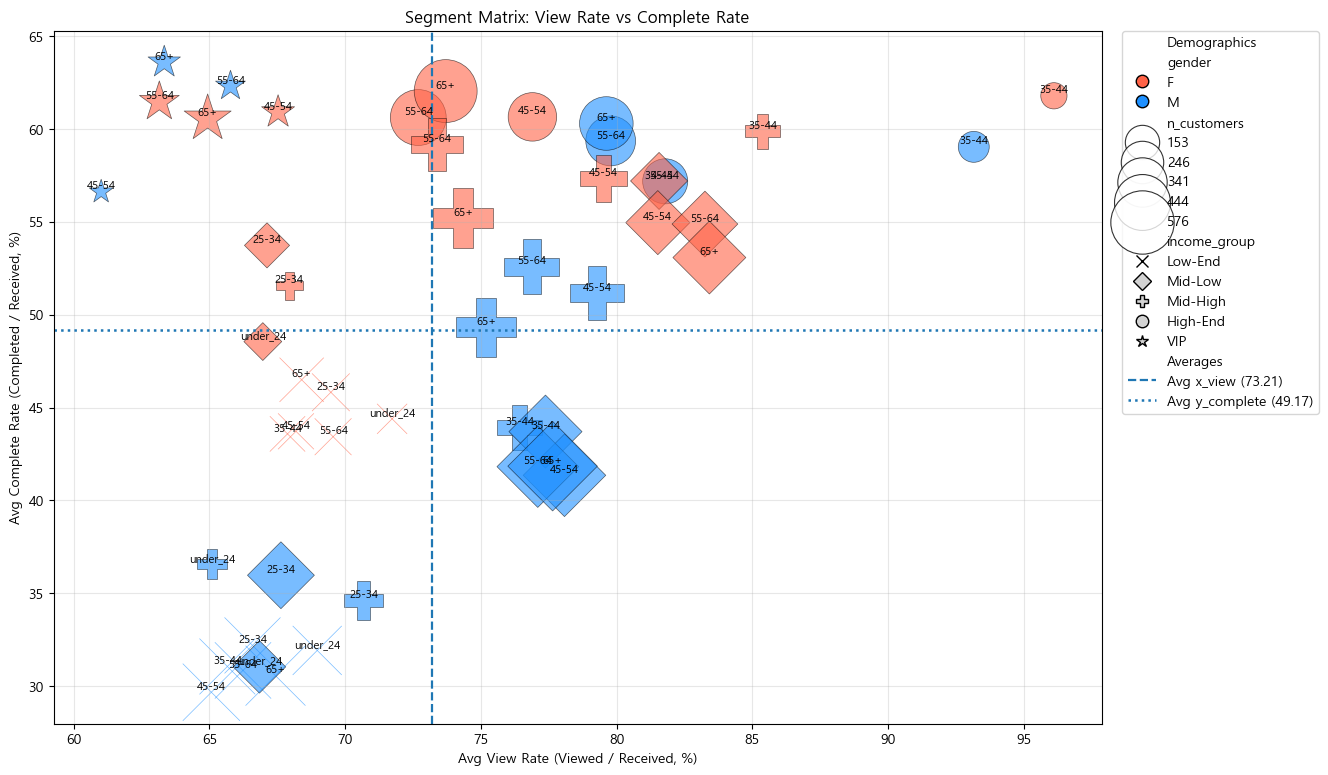

In [26]:
color_map = {"F": "tomato", "M": "dodgerblue", "O": "gray"}
marker_map = {
    "Low-End": "x",
    "Mid-Low": "D",
    "Mid": "s",
    "Mid-High": "P",
    "High-End": "o",
    "VIP": "*",
}

# 버블 크기: n_customers 기반 스케일링
n = seg_50up["n_customers"].astype(float)
seg_50up = seg_50up.copy()

if n.max() > 0:
    seg_50up["bubble"] = (n / n.max()) * 2000 + 80   # 80~2080
else:
    seg_50up["bubble"] = 200

# 그림 그리기
fig, ax = plt.subplots(figsize=(16, 9))

for inc, g_inc in seg_50up.groupby("income_g", sort=False):
    for gen, g in g_inc.groupby("gender_g", sort=False):
        ax.scatter(
            g["x_view"], g["y_complete"],
            s=g["bubble"],
            c=color_map.get(gen, "black"),
            marker=marker_map.get(inc, "o"),
            alpha=0.6,
            edgecolors="k",
            linewidths=0.5
        )

# 라벨 age_g만 표시
for _, r in seg_50up.iterrows():
    ax.text(
        r["x_view"], r["y_complete"],
        f'{r["age_g"]}',
        fontsize=8,
        ha="center",
        va="bottom"
    )

ax.set_title("Segment Matrix: View Rate vs Complete Rate")
ax.set_xlabel("Avg View Rate (Viewed / Received, %)")
ax.set_ylabel("Avg Complete Rate (Completed / Received, %)")
ax.grid(True, alpha=0.3)

# 전체 평균선 추가
x_mean = seg_50up["x_view"].mean()
y_mean = seg_50up["y_complete"].mean()

# 선 스타일/색은 여기서 조절
vline = ax.axvline(x_mean, linestyle="--", linewidth=1.6)
hline = ax.axhline(y_mean, linestyle=":",  linewidth=1.8)

# 오른쪽 레전드 공간 확보
fig.subplots_adjust(right=0.78)

# 레전드 핸들(하나의 박스로 합치기)

# 1) 섹션 헤더용 더미(텍스트처럼 보이게)
hdr_demo = Line2D([], [], linestyle="None", label="Demographics")
hdr_gender = Line2D([], [], linestyle="None", label="gender")
hdr_size = Line2D([], [], linestyle="None", label="n_customers")
hdr_income = Line2D([], [], linestyle="None", label="income_group")
hdr_lines = Line2D([], [], linestyle="None", label="Averages")

# 2) Gender (색)
gender_order = [g for g in ["F", "M", "O"] if g in seg_50up["gender_g"].unique()]
gender_handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=color_map[g], markeredgecolor='k',
           markersize=9, label=g)
    for g in gender_order
]

# 3) Income (모양만, 색은 회색 고정)
income_levels = [x for x in marker_map.keys() if x in seg_50up["income_g"].unique()]
income_handles = [
    Line2D([0], [0], marker=marker_map[inc], linestyle='None',
           markerfacecolor='lightgray', markeredgecolor='k',
           markersize=9, label=inc)
    for inc in income_levels
]

# 4) n_customers (크기)
qs = [0.2, 0.4, 0.6, 0.8, 1.0]
size_vals = np.unique(np.ceil(n.quantile(qs).values).astype(int))
size_vals = size_vals[size_vals > 0]

def to_bubble(v):
    return (v / n.max()) * 2000 + 80 if n.max() > 0 else 200

size_handles = [
    ax.scatter([], [], s=to_bubble(v),
               c="white", edgecolors="k", linewidths=0.8, alpha=0.8,
               label=str(v))
    for v in size_vals
]

# 5) 평균선 레전드 핸들 (선 색/스타일과 맞춰줌)
avg_x_handle = Line2D([0], [0], linestyle="--", linewidth=1.6,
                      label=f"Avg x_view ({x_mean:.2f})")
avg_y_handle = Line2D([0], [0], linestyle=":", linewidth=1.8,
                      label=f"Avg y_complete ({y_mean:.2f})")

# 단일 레전드로 합치기
legend_handles = (
    [hdr_demo] +
    [hdr_gender] + gender_handles +
    [hdr_size] + size_handles +
    [hdr_income] + income_handles +
    [hdr_lines, avg_x_handle, avg_y_handle]
)

leg = ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=True
)

# 헤더 줄은 아이콘 숨기기(텍스트만 보이게)
header_texts = {"Demographics", "gender", "n_customers", "income_group", "Averages"}
for txt, h in zip(leg.get_texts(), leg.legend_handles):
    if txt.get_text() in header_texts:
        h.set_visible(False)

plt.show()

In [27]:
# 고객 특성 데이터 병합 (features ← timeline)
# features에 timeline에 있는 고객 특성 컬럼 붙이기

person_info = (
    timeline[
        ['person', 'gender_g', 'age_g', 'income_g', 'membership_g', 'membership_years']
    ]
    .drop_duplicates(subset='person')
)

features_with_person = features.merge(
    person_info,
    on='person',
    how='left'
)

features_with_person

,person,tx_active_days,tx_recency_days,last_tx_day,avg_gap_days,median_gap_days,min_gap_days,max_gap_days,std_gap_days,gender_g,age_g,income_g,membership_g,membership_years
0,0009655768c64bdeb2e877511632db8f,8,0,29,2.857143,1.0,1,8,2.734262,M,25-34,Mid-High,1~3yr,1.262149
1,0011e0d4e6b944f998e987f904e8c1e5,5,2,27,5.5,3.5,1,14,5.91608,O,35-44,Mid-Low,Under 1yr,0.542094
2,0020c2b971eb4e9188eac86d93036a77,6,0,29,5.4,3.0,1,15,5.899152,F,55-64,High-End,1~3yr,2.392882
3,0020ccbbb6d84e358d3414a3ff76cffd,11,1,28,2.7,1.5,1,8,2.451757,F,under_24,Mid-Low,1~3yr,1.702943
4,003d66b6608740288d6cc97a6903f4f0,14,0,29,2.076923,1.0,1,5,1.497862,F,25-34,Mid-High,1~3yr,1.095140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14482,fff3ba4757bd42088c044ca26d73817a,10,6,23,2.555556,1.0,1,9,2.650996,F,65+,High-End,1~3yr,2.847365
14483,fff7576017104bcc8677a8d63322b5e1,6,0,29,5.6,5.0,1,12,4.219005,M,65+,Mid-High,Under 1yr,0.733744
14484,fff8957ea8b240a6b5e634b6ee8eafcf,5,5,24,6.0,4.0,1,15,6.218253,M,65+,Mid-Low,Under 1yr,0.432580
14485,fffad4f4828548d1b5583907f2e9906b,11,1,28,2.7,2.5,1,5,1.567021,M,25-34,Low-End,1~3yr,1.503080


C:\Users\noisn\AppData\Local\Temp\ipykernel_34464\922211141.py:62: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\noisn\AppData\Local\Temp\ipykernel_34464\922211141.py:62: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\noisn\AppData\Local\Temp\ipykernel_34464\922211141.py:62: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\noisn\AppData\Local\Temp\ipykernel_34464\922211141.py:62: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in

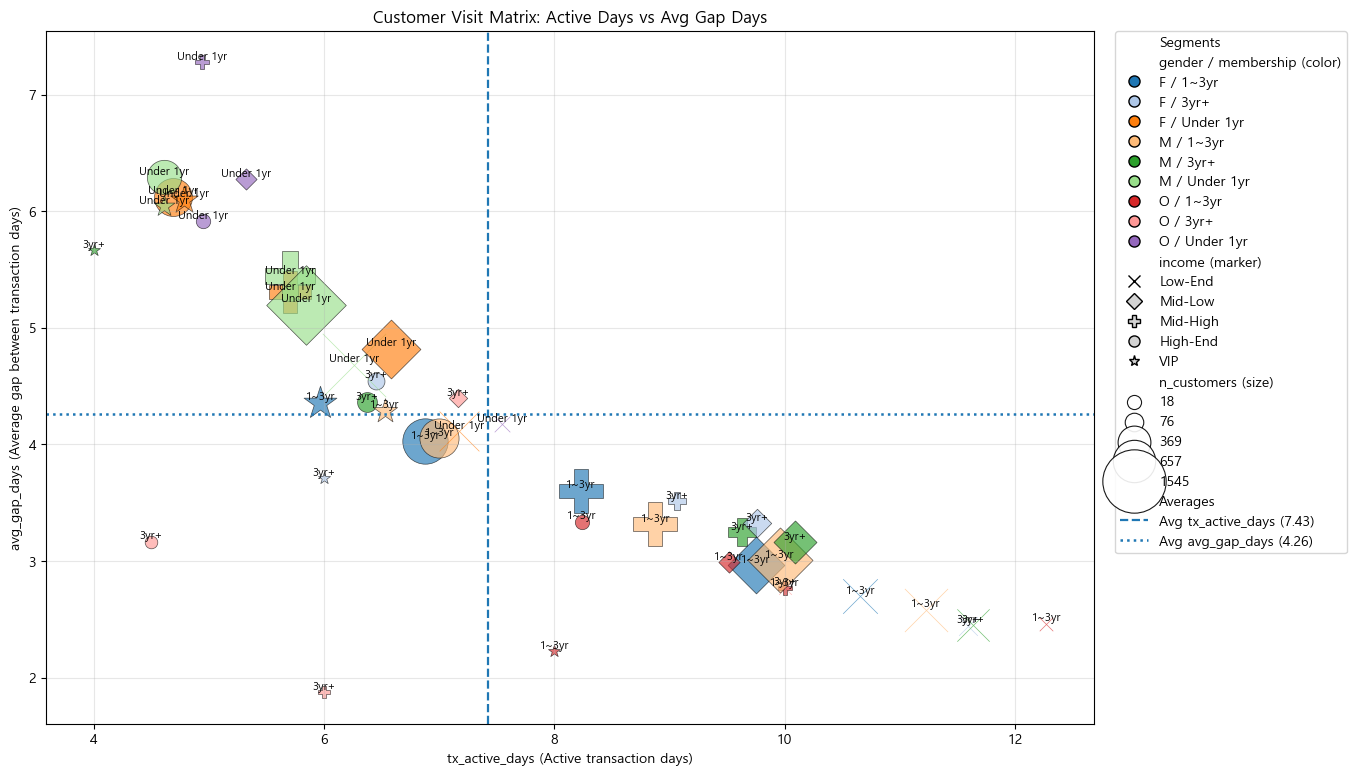

In [28]:
# 1) 세그먼트 집계 테이블 만들기

dfp = features_with_person.copy()

# 필요한 컬럼 존재 확인(없으면 여기서 KeyError 발생)
need_cols = ["person","tx_active_days","avg_gap_days","gender_g","membership_g","income_g"]
missing = [c for c in need_cols if c not in dfp.columns]
if missing:
    raise KeyError(f"features_with_person에 아래 컬럼이 없습니다: {missing}")

# 결측 제거(분석 정의에 따라 조정 가능)
dfp = dfp.dropna(subset=["tx_active_days","avg_gap_days","gender_g","membership_g","income_g"]).copy()

# 세그먼트(점) 생성: income + gender + membership 조합
seg = (
    dfp.groupby(["income_g","gender_g","membership_g"], as_index=False)
       .agg(
           x=("tx_active_days","mean"),
           y=("avg_gap_days","mean"),
           n_customers=("person","nunique")
       )
)

# 2) 버블 크기 스케일링 (n_customers)
n = seg["n_customers"].astype(float)
if n.max() > 0:
    seg["bubble"] = (n / n.max()) * 2000 + 80   # 80~2080
else:
    seg["bubble"] = 200


# 3) 색/마커 매핑
# income -> marker
marker_map = {
    "Low-End": "x",
    "Mid-Low": "D",
    "Mid": "s",
    "Mid-High": "P",
    "High-End": "o",
    "VIP": "*",
}

# (gender, membership) 조합 만들기
seg["gm_key"] = seg["gender_g"].astype(str) + " / " + seg["membership_g"].astype(str)

# 조합별 색 지정
gm_levels = seg["gm_key"].dropna().unique().tolist()
cmap = plt.get_cmap("tab20") 
gm_color_map = {k: cmap(i % cmap.N) for i, k in enumerate(gm_levels)}


# 4) 전체 평균선(점선)
x_mean = dfp["tx_active_days"].mean()
y_mean = dfp["avg_gap_days"].mean()

# 5) 플롯
fig, ax = plt.subplots(figsize=(16, 9))

# 점 그리기
for inc, g_inc in seg.groupby("income_g", sort=False):
    for gm, g in g_inc.groupby("gm_key", sort=False):
        ax.scatter(
            g["x"], g["y"],
            s=g["bubble"],
            marker=marker_map.get(inc, "o"),
            c=[gm_color_map.get(gm, "gray")],
            alpha=0.65,
            edgecolors="k",
            linewidths=0.5
        )

# 라벨
for _, r in seg.iterrows():
    ax.text(
        r["x"], r["y"],
        f'{r["membership_g"]}',
        fontsize=8,
        ha="center",
        va="bottom"
    )

# 평균선
vline = ax.axvline(x_mean, linestyle="--", linewidth=1.6)  # 색 자동
hline = ax.axhline(y_mean, linestyle=":", linewidth=1.8)   # 색 자동

ax.set_title("Customer Visit Matrix: Active Days vs Avg Gap Days")
ax.set_xlabel("tx_active_days (Active transaction days)")
ax.set_ylabel("avg_gap_days (Average gap between transaction days)")
ax.grid(True, alpha=0.3)

# 오른쪽 레전드 자리 확보
fig.subplots_adjust(right=0.78)


# 6) 레전드(하나의 박스에 섹션별로)

# 섹션 헤더용 더미
hdr_demo = Line2D([], [], linestyle="None", label="Segments")
hdr_color = Line2D([], [], linestyle="None", label="gender / membership (color)")
hdr_marker = Line2D([], [], linestyle="None", label="income (marker)")
hdr_size = Line2D([], [], linestyle="None", label="n_customers (size)")
hdr_avg = Line2D([], [], linestyle="None", label="Averages")

# (A) color legend: gender/membership 조합
color_handles = [
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor=gm_color_map[k], markeredgecolor='k',
           markersize=8, label=k)
    for k in gm_levels
]

# (B) marker legend: income
income_levels = [k for k in marker_map.keys() if k in seg["income_g"].unique()]
marker_handles = [
    Line2D([0],[0], marker=marker_map[k], linestyle='None',
           markerfacecolor='lightgray', markeredgecolor='k',
           markersize=8, label=k)
    for k in income_levels
]

# (C) size legend: n_customers 대표 값
qs = [0.2, 0.4, 0.6, 0.8, 1.0]
size_vals = np.unique(np.ceil(n.quantile(qs).values).astype(int))
size_vals = size_vals[size_vals > 0]

def to_bubble(v):
    return (v / n.max()) * 2000 + 80 if n.max() > 0 else 200

size_handles = [
    ax.scatter([], [], s=to_bubble(v),
               c="white", edgecolors="k", linewidths=0.8, alpha=0.9,
               label=str(v))
    for v in size_vals
]

# (D) 평균선 레전드
avg_x_handle = Line2D([0],[0], linestyle="--", linewidth=1.6, label=f"Avg tx_active_days ({x_mean:.2f})")
avg_y_handle = Line2D([0],[0], linestyle=":", linewidth=1.8, label=f"Avg avg_gap_days ({y_mean:.2f})")

legend_handles = (
    [hdr_demo] +
    [hdr_color] + color_handles +
    [hdr_marker] + marker_handles +
    [hdr_size] + size_handles +
    [hdr_avg, avg_x_handle, avg_y_handle]
)

leg = ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=True
)

# 헤더 줄은 아이콘 숨기기(텍스트만)
header_texts = {"Segments", "gender / membership (color)", "income (marker)", "n_customers (size)", "Averages"}
for txt, h in zip(leg.get_texts(), leg.legend_handles):
    if txt.get_text() in header_texts:
        h.set_visible(False)

plt.show()

In [29]:
# membership 재범주화 + 세그먼트 재집계 + seg 재집계 + n_customers 필터

# A) membership_g 재범주화 (person 레벨 dfp에서 먼저)

dfp = features_with_person.copy()

# membership_years가 있으면 이게 가장 안전합니다.
if "membership_years" in dfp.columns:
    dfp["membership_bin"] = np.where(dfp["membership_years"] < 1, "Under 1yr", "1yr+")
else:
    # membership_years가 없다면 membership_g 문자열 기반으로 처리(필요시 규칙 수정)
    dfp["membership_bin"] = np.where(
        dfp["membership_g"].astype(str).str.contains("Under", case=False, na=False),
        "Under 1yr",
        "1yr+"
    )

# B) seg를 membership_bin 기준으로 다시 집계

seg = (
    dfp.groupby(["income_g", "gender_g", "membership_bin"], as_index=False)
       .agg(
           x=("tx_active_days", "mean"),
           y=("avg_gap_days", "mean"),
           n_customers=("person", "nunique")
       )
)

# n_customers 22 이상만
seg = seg[seg["n_customers"] >= 30].copy()

seg


,income_g,gender_g,membership_bin,x,y,n_customers
0,High-End,F,1yr+,6.795152,4.059612,825
1,High-End,F,Under 1yr,4.427027,6.125024,555
2,High-End,M,1yr+,6.890769,4.101019,650
3,High-End,M,Under 1yr,4.302222,6.29073,450
6,Low-End,F,1yr+,10.806841,2.659529,497
7,Low-End,F,Under 1yr,7.044674,4.111348,582
8,Low-End,M,1yr+,11.367562,2.538854,1042
9,Low-End,M,Under 1yr,6.144304,4.684636,1580
11,Low-End,O,Under 1yr,7.542857,4.174548,35
12,Mid-High,F,1yr+,8.244681,3.596839,752


## 6. LTV 기반 검증

고객 생애 가치(LTV) 산출로 루틴형 고객의 비즈니스 가치 확인  
→ LTV 높은 그룹과 루틴형 고객 분류 결과 교차 검증

---

C:\Users\noisn\AppData\Local\Temp\ipykernel_34464\476303885.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\noisn\AppData\Local\Temp\ipykernel_34464\476303885.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\noisn\AppData\Local\Temp\ipykernel_34464\476303885.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\noisn\AppData\Local\Temp\ipykernel_34464\476303885.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in

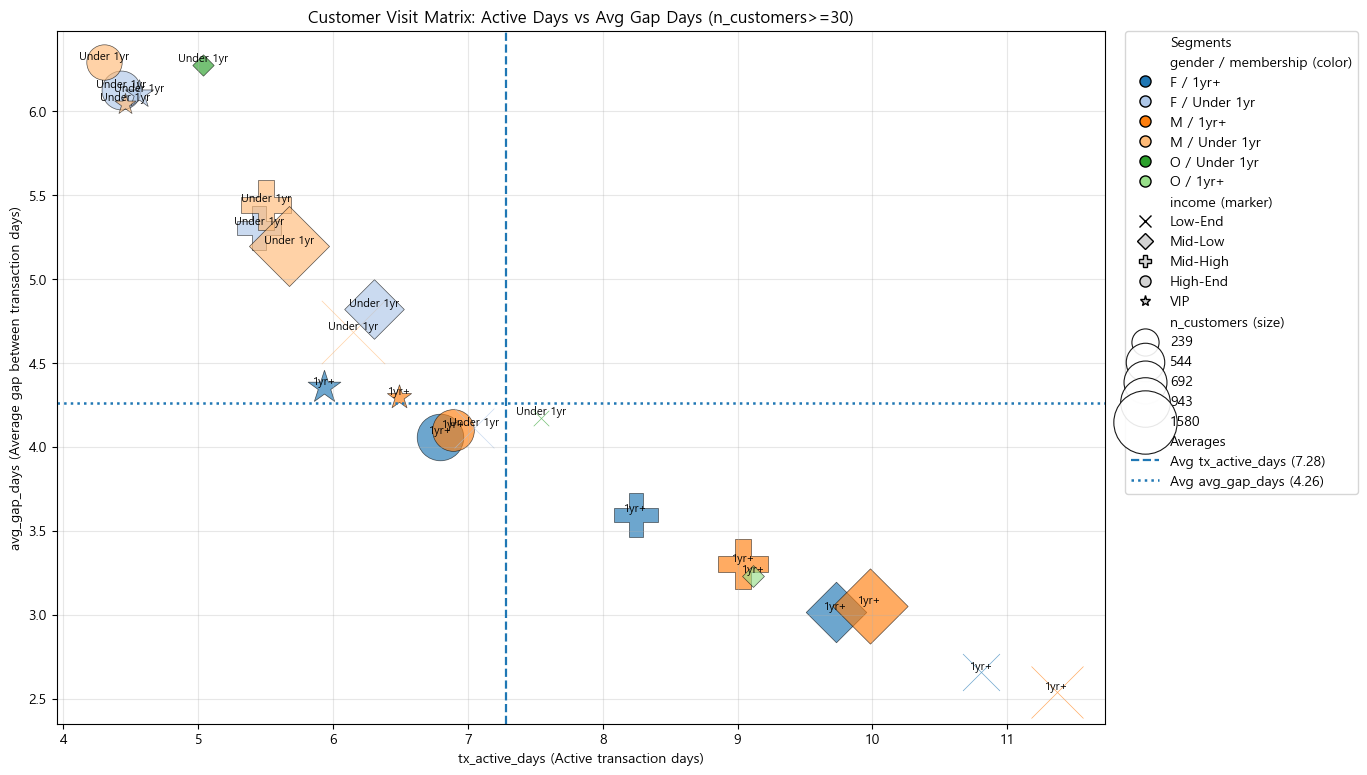

In [30]:

# 버블 크기
n = seg["n_customers"].astype(float)
seg = seg.copy()
seg["bubble"] = (n / n.max()) * 2000 + 80 if n.max() > 0 else 200

# 마커 매핑
marker_map = {
    "Low-End": "x",
    "Mid-Low": "D",
    "Mid": "s",
    "Mid-High": "P",
    "High-End": "o",
    "VIP": "*",
}

# 색 매핑: gender x membership_bin
seg["gm_key"] = seg["gender_g"].astype(str) + " / " + seg["membership_bin"].astype(str)
gm_levels = seg["gm_key"].dropna().unique().tolist()
cmap = plt.get_cmap("tab20")
gm_color_map = {k: cmap(i % cmap.N) for i, k in enumerate(gm_levels)}

# 전체 평균선
# 1) dfp 전체 기준
x_mean = dfp["tx_active_days"].mean()
y_mean = dfp["avg_gap_days"].mean()


# 그림 그리기
fig, ax = plt.subplots(figsize=(16, 9))

for inc, g_inc in seg.groupby("income_g", sort=False):
    for gm, g in g_inc.groupby("gm_key", sort=False):
        ax.scatter(
            g["x"], g["y"],
            s=g["bubble"],
            marker=marker_map.get(inc, "o"),
            c=[gm_color_map.get(gm, "gray")],
            alpha=0.65,
            edgecolors="k",
            linewidths=0.5
        )

# 라벨: membership_bin
for _, r in seg.iterrows():
    ax.text(r["x"], r["y"], f'{r["membership_bin"]}', fontsize=8, ha="center", va="bottom")

# 평균선
ax.axvline(x_mean, linestyle="--", linewidth=1.6)
ax.axhline(y_mean, linestyle=":", linewidth=1.8)

ax.set_title("Customer Visit Matrix: Active Days vs Avg Gap Days (n_customers>=30)")
ax.set_xlabel("tx_active_days (Active transaction days)")
ax.set_ylabel("avg_gap_days (Average gap between transaction days)")
ax.grid(True, alpha=0.3)

fig.subplots_adjust(right=0.78)

# 레전드
hdr_demo = Line2D([], [], linestyle="None", label="Segments")
hdr_color = Line2D([], [], linestyle="None", label="gender / membership (color)")
hdr_marker = Line2D([], [], linestyle="None", label="income (marker)")
hdr_size = Line2D([], [], linestyle="None", label="n_customers (size)")
hdr_avg = Line2D([], [], linestyle="None", label="Averages")

color_handles = [
    Line2D([0],[0], marker='o', linestyle='None',
           markerfacecolor=gm_color_map[k], markeredgecolor='k',
           markersize=8, label=k)
    for k in gm_levels
]

income_levels = [k for k in marker_map.keys() if k in seg["income_g"].unique()]
marker_handles = [
    Line2D([0],[0], marker=marker_map[k], linestyle='None',
           markerfacecolor='lightgray', markeredgecolor='k',
           markersize=8, label=k)
    for k in income_levels
]

qs = [0.2, 0.4, 0.6, 0.8, 1.0]
size_vals = np.unique(np.ceil(n.quantile(qs).values).astype(int))
size_vals = size_vals[size_vals > 0]

def to_bubble(v):
    return (v / n.max()) * 2000 + 80 if n.max() > 0 else 200

size_handles = [
    ax.scatter([], [], s=to_bubble(v),
               c="white", edgecolors="k", linewidths=0.8, alpha=0.9,
               label=str(v))
    for v in size_vals
]

avg_x_handle = Line2D([0],[0], linestyle="--", linewidth=1.6, label=f"Avg tx_active_days ({x_mean:.2f})")
avg_y_handle = Line2D([0],[0], linestyle=":", linewidth=1.8, label=f"Avg avg_gap_days ({y_mean:.2f})")

legend_handles = (
    [hdr_demo] +
    [hdr_color] + color_handles +
    [hdr_marker] + marker_handles +
    [hdr_size] + size_handles +
    [hdr_avg, avg_x_handle, avg_y_handle]
)

leg = ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=True
)

header_texts = {"Segments", "gender / membership (color)", "income (marker)", "n_customers (size)", "Averages"}
for txt, h in zip(leg.get_texts(), leg.legend_handles):
    if txt.get_text() in header_texts:
        h.set_visible(False)

plt.show()

In [31]:
# LTV 분석을 위한 기본 데이터
df3 = mt.copy()
purchase = df3[df3['event'] == 'transaction'].copy()

In [32]:
# 고객별 총 거래 금액 집계 (Monetary)
customer_monetary = purchase.groupby('person')['amount'].sum().reset_index()
customer_monetary.columns = ['person', 'total_amt']

## 고객별 거래 누적 빈도
customer_freq = purchase.groupby('person').size().reset_index(name='tx_cnt')

## 고객별 활동 기간 (첫 구매 ~ 마지막 구매)
customer_life = purchase.groupby('person')['time'].agg(['min', 'max']).reset_index()
customer_life['active_hrs'] = (customer_life['max'] - customer_life['min'])
customer_life['active_days'] = (customer_life['max'] - customer_life['min']) / 24

In [33]:
# LTV 구성 변수 병합

customer_ltv = customer_monetary \
    .merge(customer_freq, on='person') \
    .merge(customer_life[['person', 'active_hrs', 'active_days']], on='person')

customer_ltv.head()

,person,total_amt,tx_cnt,active_hrs,active_days
0,0009655768c64bdeb2e877511632db8f,127.60,8,468,19.50
1,0011e0d4e6b944f998e987f904e8c1e5,79.46,5,522,21.75
2,0020c2b971eb4e9188eac86d93036a77,196.86,8,654,27.25
3,0020ccbbb6d84e358d3414a3ff76cffd,154.05,12,630,26.25
4,003d66b6608740288d6cc97a6903f4f0,48.34,18,630,26.25


In [34]:
# LTV 스코어 계산 — 총액 × 빈도 / 기간
customer_ltv['ltv_score'] = (
    customer_ltv['total_amt'] *
    customer_ltv['tx_cnt'] /
    (customer_ltv['active_days'] + 1)
)

## LTV 범주화
customer_ltv['ltv_group'] = pd.qcut(
    customer_ltv['ltv_score'],
    q=3,
    labels=['Low', 'Mid', 'High']
)

customer_ltv

,person,total_amt,tx_cnt,active_hrs,active_days,ltv_score,ltv_group
0,0009655768c64bdeb2e877511632db8f,127.60,8,468,19.50,49.795122,High
1,0011e0d4e6b944f998e987f904e8c1e5,79.46,5,522,21.75,17.463736,Mid
2,0020c2b971eb4e9188eac86d93036a77,196.86,8,654,27.25,55.747965,High
3,0020ccbbb6d84e358d3414a3ff76cffd,154.05,12,630,26.25,67.838532,High
4,003d66b6608740288d6cc97a6903f4f0,48.34,18,630,26.25,31.931009,Mid
...,...,...,...,...,...,...,...
14482,fff3ba4757bd42088c044ca26d73817a,192.76,10,546,22.75,81.162105,High
14483,fff7576017104bcc8677a8d63322b5e1,29.94,6,660,27.50,6.303158,Low
14484,fff8957ea8b240a6b5e634b6ee8eafcf,12.15,5,558,23.25,2.505155,Low
14485,fffad4f4828548d1b5583907f2e9906b,88.83,12,642,26.75,38.412973,Mid


In [35]:
# 오퍼 반응 데이터 병합

offer_complete = df3[df3['event'] == 'offer completed']

# 완료 횟수 구하기
offer_cnt = offer_complete.groupby('person').size().reset_index(name='offer_completed')

customer_ltv = customer_ltv.merge(offer_cnt, on='person', how='left')
customer_ltv['offer_completed'] = customer_ltv['offer_completed'].fillna(0)

customer_ltv.head()

,person,total_amt,tx_cnt,active_hrs,active_days,ltv_score,ltv_group,offer_completed
0,0009655768c64bdeb2e877511632db8f,127.60,8,468,19.50,49.795122,High,3.0
1,0011e0d4e6b944f998e987f904e8c1e5,79.46,5,522,21.75,17.463736,Mid,3.0
2,0020c2b971eb4e9188eac86d93036a77,196.86,8,654,27.25,55.747965,High,3.0
3,0020ccbbb6d84e358d3414a3ff76cffd,154.05,12,630,26.25,67.838532,High,3.0
4,003d66b6608740288d6cc97a6903f4f0,48.34,18,630,26.25,31.931009,Mid,3.0


In [36]:
# viewed / completed 이벤트 분리

viewed = df3[df3['event'] == 'offer viewed'][['person', 'offer_id', 'time']]
completed = df3[df3['event'] == 'offer completed'][['person', 'offer_id', 'time']]

## viewed → completed
vc = completed.merge(
    viewed,
    on=['person', 'offer_id'],
    suffixes=('_completed', '_viewed')
)

vc_valid = vc[vc['time_viewed'] < vc['time_completed']]

## 고객별 개수
vc_count = vc_valid.groupby('person').size().reset_index(name='viewed_to_completed')


In [37]:
# 우연완료 건수 계산 — viewed 없이 completed된 케이스
# 전체 completed - 정상 (viewed → completed)

completed_count = completed.groupby('person').size().reset_index(name='total_completed')

completed_summary = completed_count.merge(
    vc_count,
    on='person',
    how='left'
).fillna(0)

completed_summary['completed_without_view'] = (
    completed_summary['total_completed'] -
    completed_summary['viewed_to_completed']
)

In [38]:
# 우연완료 지표를 LTV 테이블에 병합

customer_ltv = customer_ltv.merge(
    completed_summary[['person', 'viewed_to_completed', 'completed_without_view']],
    on='person',
    how='left'
)

customer_ltv[['viewed_to_completed', 'completed_without_view']] = (
    customer_ltv[['viewed_to_completed', 'completed_without_view']].fillna(0)
)

customer_ltv

,person,total_amt,tx_cnt,active_hrs,active_days,ltv_score,ltv_group,offer_completed,viewed_to_completed,completed_without_view
0,0009655768c64bdeb2e877511632db8f,127.60,8,468,19.50,49.795122,High,3.0,0.0,3.0
1,0011e0d4e6b944f998e987f904e8c1e5,79.46,5,522,21.75,17.463736,Mid,3.0,3.0,0.0
2,0020c2b971eb4e9188eac86d93036a77,196.86,8,654,27.25,55.747965,High,3.0,3.0,0.0
3,0020ccbbb6d84e358d3414a3ff76cffd,154.05,12,630,26.25,67.838532,High,3.0,3.0,0.0
4,003d66b6608740288d6cc97a6903f4f0,48.34,18,630,26.25,31.931009,Mid,3.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...
14482,fff3ba4757bd42088c044ca26d73817a,192.76,10,546,22.75,81.162105,High,3.0,0.0,3.0
14483,fff7576017104bcc8677a8d63322b5e1,29.94,6,660,27.50,6.303158,Low,3.0,3.0,0.0
14484,fff8957ea8b240a6b5e634b6ee8eafcf,12.15,5,558,23.25,2.505155,Low,0.0,0.0,0.0
14485,fffad4f4828548d1b5583907f2e9906b,88.83,12,642,26.75,38.412973,Mid,3.0,3.0,0.0


In [39]:
# 오퍼 반응 컬럼 선택 후 LTV 그룹별 평균 비교
value_cols = [
    'offer_completed',
    'viewed_to_completed',
    'completed_without_view'
]


## LTV 그룹별 평균 계산
heatmap_df = (
    customer_ltv
    .groupby('ltv_group')[value_cols]
    .mean()
)

C:\Users\noisn\AppData\Local\Temp\ipykernel_34464\667298407.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('ltv_group')[value_cols]


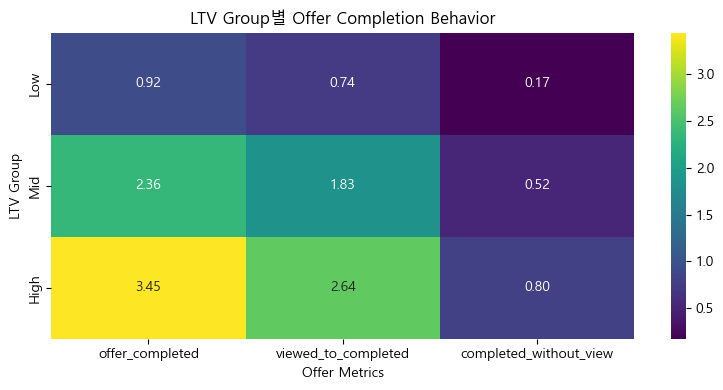

In [40]:
# LTV 그룹 × 오퍼 반응 히트맵

rc('font', family='Malgun Gothic')

plt.figure(figsize=(8, 4))
sns.heatmap(
    heatmap_df,
    annot=True,        # 숫자 표시
    fmt=".2f",
    cmap="viridis"
)

plt.title("LTV Group별 Offer Completion Behavior")
plt.ylabel("LTV Group")
plt.xlabel("Offer Metrics")

plt.tight_layout()
plt.show()

In [41]:
# 고객 특성 (성별·연령·소득) 병합

customer_ltv2 = customer_ltv.merge(
    df3[['person', 'gender_g', 'age_g', 'income_g']],
    on='person',
    how='left'
)

customer_ltv2

,person,total_amt,tx_cnt,active_hrs,active_days,ltv_score,ltv_group,offer_completed,viewed_to_completed,completed_without_view,gender_g,age_g,income_g
0,0009655768c64bdeb2e877511632db8f,127.60,8,468,19.5,49.795122,High,3.0,0.0,3.0,M,25-34,Mid-High
1,0009655768c64bdeb2e877511632db8f,127.60,8,468,19.5,49.795122,High,3.0,0.0,3.0,M,25-34,Mid-High
2,0009655768c64bdeb2e877511632db8f,127.60,8,468,19.5,49.795122,High,3.0,0.0,3.0,M,25-34,Mid-High
3,0009655768c64bdeb2e877511632db8f,127.60,8,468,19.5,49.795122,High,3.0,0.0,3.0,M,25-34,Mid-High
4,0009655768c64bdeb2e877511632db8f,127.60,8,468,19.5,49.795122,High,3.0,0.0,3.0,M,25-34,Mid-High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
268926,ffff82501cea40309d5fdd7edcca4a07,226.07,15,588,24.5,132.982353,High,6.0,6.0,0.0,F,45-54,Mid-Low
268927,ffff82501cea40309d5fdd7edcca4a07,226.07,15,588,24.5,132.982353,High,6.0,6.0,0.0,F,45-54,Mid-Low
268928,ffff82501cea40309d5fdd7edcca4a07,226.07,15,588,24.5,132.982353,High,6.0,6.0,0.0,F,45-54,Mid-Low
268929,ffff82501cea40309d5fdd7edcca4a07,226.07,15,588,24.5,132.982353,High,6.0,6.0,0.0,F,45-54,Mid-Low


## 7. 오퍼 축소 시뮬레이션 (손익 계산)

**시나리오:** 루틴형 고객(상위 30%)에게 오퍼를 50% 축소 발송

| 항목 | 예상 수치 |
|------|----------|
| 대상 고객 수 | 전체의 30% |
| 오퍼 감소량 | 50% 축소 |
| 예상 매출 손실 | 계산값 참조 |
| 리워드 비용 절감 | 매출 손실 초과 |

→ 비용 절감이 매출 손실을 상회 → 순이익 개선

---

In [42]:
# ================================
# Routine Score 파라미터 설정
# - routine_top_pct: 상위 몇 %를 루틴형으로 정의할지 (30%)
# - 가중치: 방문일수(45%) > 방문간격(35%) > 오퍼없는거래비율(20%)
# - keep_rate: 루틴형 고객에게 오퍼를 얼마나 유지할지 (50%)
# ================================
# 0) 사용자 입력(리서치/정책 파라미터)

PARAM = {
    # 루틴형 정의 기준
    "routine_top_pct": 0.30,

    # 루틴 스코어 가중치
    "w_active_days": 0.45,
    "w_gap_days": 0.35,
    "w_tx_per_offer": 0.20,

    # 시나리오
    "keep_rate_by_offer_type": {
        "discount": 0.50,
        "bogo":0.50,
        "informational": 1.00
    },

    # 비용
    "send_cost_per_offer": 0.0,

    # reward 비용 추정 방식
    "fallback_reward_cost_by_offer_type": {
        "discount": 3.0,       # discount 평균 reward
        "bogo": 7.5,           # bogo 평균 reward
        "informational": 0.0
    },

    # 손실(증분) 추정
    "incrementality_rate_by_offer_type": {
        "discount": 0.05,
        "bogo": 0.12,
        "informational": 0.02
    },

    # 강한 반응(Strongly influenced) 정의
    # received 대비 viewed+completed가 모두 있는 오퍼
    "strong_requires_view_and_complete": True,

    "tx_attribution_method": "asof",
}

In [43]:
# 1) 입력 테이블 준비

tl = timeline.copy()

# 필수 컬럼 체크
need_cols = ["person","event","event_time","offer_id","offer_instance","received_time","expiry_time",
             "offer_type","amount","gender_g","age_g","income_g","membership_g"]
missing = [c for c in need_cols if c not in tl.columns]
if missing:
    raise KeyError(f"tl(timeline) 에 아래 컬럼이 없습니다: {missing}")

# event_time dtype 정리
tl["event_time"] = pd.to_numeric(tl["event_time"], errors="coerce")

In [44]:
# 2) 고객별 방문 지표(루틴성) 계산

# 2-1) 거래만
tx = tl[tl["event"].eq("transaction")].copy()
tx = tx.dropna(subset=["person","event_time"])
tx["day"] = (tx["event_time"] // 24).astype("Int64")  # 24시간=1일 (데이터 정의에 맞게 유지)

# 고객별 거래 발생 '일수'
tx_days = tx.groupby("person", as_index=False).agg(tx_active_days=("day","nunique"))

# 고객별 방문 주기(거래일 간격)
tx_days_sorted = (
    tx[["person","day"]]
    .drop_duplicates()
    .sort_values(["person","day"])
)
tx_days_sorted["gap_days"] = tx_days_sorted.groupby("person")["day"].diff()

gap_summary = (
    tx_days_sorted.groupby("person", as_index=False)
    .agg(
        avg_gap_days=("gap_days","mean"),
        median_gap_days=("gap_days","median"),
        min_gap_days=("gap_days","min"),
        max_gap_days=("gap_days","max"),
        std_gap_days=("gap_days","std"),
    )
)

# 2-2) 고객별 오퍼 received 수
recv = tl[tl["event"].eq("offer received")].copy()
recv = recv.dropna(subset=["person","offer_id","offer_instance","received_time"])

offer_counts = (
    recv.groupby("person", as_index=False)
        .agg(n_received=("offer_instance","size"))
)

# 2-3) 고객별 tx_per_offer
cust = tx_days.merge(gap_summary, on="person", how="left").merge(offer_counts, on="person", how="left")
cust["n_received"] = cust["n_received"].fillna(0)

# 거래 이벤트 수(건수)도 같이 보관(옵션)
tx_cnt = tx.groupby("person", as_index=False).agg(n_tx=("event_time","size"))
cust = cust.merge(tx_cnt, on="person", how="left")
cust["n_tx"] = cust["n_tx"].fillna(0)

# 거래/오퍼노출 비율
cust["tx_per_offer"] = np.where(cust["n_received"] > 0, cust["n_tx"] / cust["n_received"], np.nan)

# 고객 특성(대표값)
person_info = (
    tl[["person","gender_g","age_g","income_g","membership_g","membership_years"]]
    .drop_duplicates(subset="person")
)
cust = cust.merge(person_info, on="person", how="left")

In [45]:
# 각 지표를 z-score로 표준화 후 가중 합산
# → 단위가 다른 지표들을 동등하게 비교하기 위함
# 상위 30%가 Routine Score 기준선 이상 = 루틴형 고객
# 3) 루틴 스코어 만들고 루틴형 customer 선정

def zscore(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    return (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else 1.0)

tmp = cust.copy()

# norm: active_days 높을수록 +, gap_days 낮을수록 +, tx_per_offer 높을수록 +
tmp["z_active"] = zscore(tmp["tx_active_days"].fillna(0))
tmp["z_gap_inv"] = zscore((-tmp["avg_gap_days"]).fillna(0))  # gap 낮을수록 + 되도록 음수
tmp["z_tx_per_offer"] = zscore(tmp["tx_per_offer"].fillna(0))

tmp["routine_score"] = (
    PARAM["w_active_days"] * tmp["z_active"] +
    PARAM["w_gap_days"] * tmp["z_gap_inv"] +
    PARAM["w_tx_per_offer"] * tmp["z_tx_per_offer"]
)

# 상위 routine_top_pct를 루틴형으로
cut = tmp["routine_score"].quantile(1 - PARAM["routine_top_pct"])
tmp["is_routine"] = (tmp["routine_score"] >= cut).astype(int)

routine_persons = set(tmp.loc[tmp["is_routine"].eq(1), "person"])

In [46]:
# 4) 오퍼 반응(Received 대비 Viewed/Completed) + (옵션) Strong 정의

# 오퍼 단위 key
key_cols = ["person","offer_id","offer_instance"]

# offer received time / expiry time
recv_keys = (
    tl[tl["event"].eq("offer received")]
    .dropna(subset=key_cols + ["received_time","expiry_time"])
    .groupby(key_cols, as_index=False)
    .agg(received_time=("received_time","min"), expiry_time=("expiry_time","max"),
         offer_type=("offer_type","first"))
)

view_keys = (
    tl[tl["event"].eq("offer viewed")]
    .dropna(subset=key_cols + ["event_time"])
    .groupby(key_cols, as_index=False)
    .agg(viewed_time=("event_time","min"))
)

comp_keys = (
    tl[tl["event"].eq("offer completed")]
    .dropna(subset=key_cols + ["event_time"])
    .groupby(key_cols, as_index=False)
    .agg(completed_time=("event_time","min"))
)

offer_status = recv_keys.merge(view_keys, on=key_cols, how="left").merge(comp_keys, on=key_cols, how="left")
offer_status["is_viewed"] = offer_status["viewed_time"].notna().astype(int)
offer_status["is_completed"] = offer_status["completed_time"].notna().astype(int)

# "강한 반응" 정의
if PARAM["strong_requires_view_and_complete"]:
    offer_status["is_strong"] = ((offer_status["is_viewed"] == 1) & (offer_status["is_completed"] == 1)).astype(int)
else:
    offer_status["is_strong"] = (offer_status["is_completed"] == 1).astype(int)

# 고객별 비율
offer_by_person = (
    offer_status.groupby("person", as_index=False)
    .agg(
        n_received=("offer_instance","size"),
        n_viewed=("is_viewed","sum"),
        n_completed=("is_completed","sum"),
        n_strong=("is_strong","sum"),
    )
)
offer_by_person["view_rate"] = np.where(offer_by_person["n_received"] > 0,
                                        offer_by_person["n_viewed"] / offer_by_person["n_received"], np.nan)
offer_by_person["complete_rate"] = np.where(offer_by_person["n_received"] > 0,
                                            offer_by_person["n_completed"] / offer_by_person["n_received"], np.nan)

tmp = tmp.merge(offer_by_person, on="person", how="left")

In [47]:
# 오퍼 축소 시뮬레이션
# keep_rate=0.5: 루틴형 고객에게 기존 오퍼의 50%만 발송
# → 절감액 = 제거된 오퍼 수 × 평균 리워드 비용
# 5) 시나리오 적용: 루틴형에게 오퍼를 얼마나 줄일지 계산

# 오퍼 1행 = received 1건으로 계산
recv_rows = recv_keys.copy()
recv_rows["is_routine"] = recv_rows["person"].isin(routine_persons).astype(int)

# keep_rate 적용
def keep_rate(offer_type: str) -> float:
    return float(PARAM["keep_rate_by_offer_type"].get(offer_type, 1.0))

recv_rows["keep_rate"] = recv_rows["offer_type"].map(keep_rate).astype(float)

# 루틴형이 아닌 고객은 keep_rate=1 (정책 범위를 루틴형으로 제한)
recv_rows.loc[recv_rows["is_routine"].eq(0), "keep_rate"] = 1.0

# 줄이는 비율
recv_rows["drop_rate"] = 1.0 - recv_rows["keep_rate"]

# reward 비용(없으면 fallback)
if "reward" in tl.columns:
    reward_map = (
        tl[["offer_type","reward"]]
        .copy()
        .assign(reward=lambda d: pd.to_numeric(d["reward"], errors="coerce"))
        .groupby("offer_type", as_index=False)["reward"]
        .mean()
        .set_index("offer_type")["reward"]
        .to_dict()
    )
else:
    reward_map = {}

def reward_cost(offer_type: str) -> float:
    v = reward_map.get(offer_type, np.nan)
    if pd.isna(v):
        v = PARAM["fallback_reward_cost_by_offer_type"].get(offer_type, 0.0)
    return float(v)

recv_rows["reward_cost"] = recv_rows["offer_type"].map(reward_cost).astype(float)

# 발송비
recv_rows["send_cost"] = float(PARAM["send_cost_per_offer"])

# 줄인 오퍼 수(기대값) = drop_rate의 합
recv_rows["dropped_expected"] = recv_rows["drop_rate"]

# 절감액(기대값)
recv_rows["saved_cost_expected"] = recv_rows["dropped_expected"] * (recv_rows["send_cost"] + recv_rows["reward_cost"])

saved_cost_total = recv_rows["saved_cost_expected"].sum()

In [48]:
# 6) 손실(보수적 상한) 추정

# 6-1) 거래를 오퍼 윈도우로 귀속 (person별 merge_asof)
tx2 = tx[["person","event_time","amount"]].copy()
tx2["amount"] = pd.to_numeric(tx2["amount"], errors="coerce")
tx2["event_time"] = pd.to_numeric(tx2["event_time"], errors="coerce")
tx2 = tx2.dropna(subset=["person","event_time","amount"])
tx2["event_time"] = tx2["event_time"].astype(float)

win = recv_keys[["person","offer_id","offer_instance","received_time","expiry_time","offer_type"]].copy()
win["received_time"] = pd.to_numeric(win["received_time"], errors="coerce").astype(float)
win["expiry_time"] = pd.to_numeric(win["expiry_time"], errors="coerce").astype(float)
win = win.dropna(subset=["person","offer_id","offer_instance","received_time","expiry_time"])

matched = []

for p, g_tx in tx2.groupby("person", sort=False):
    g_win = win.loc[win["person"].eq(p)].sort_values("received_time")
    if g_win.empty:
        continue

    g_win_r = g_win.drop(columns=["person"])

    g_tx_l = g_tx.sort_values("event_time").copy()

    m = pd.merge_asof(
        g_tx_l,
        g_win_r,
        left_on="event_time",
        right_on="received_time",
        direction="backward",
        allow_exact_matches=True
    )

    # 윈도우 안에 들어온 거래만
    m = m[m["received_time"].notna() & (m["event_time"] <= m["expiry_time"])].copy()
    if m.empty:
        continue

    m["person"] = p

    matched.append(m)

tx_attr = (
    pd.concat(matched, ignore_index=True)
    if matched
    else pd.DataFrame(columns=["person","event_time","amount","offer_id","offer_instance",
                               "received_time","expiry_time","offer_type"])
)

# 6-2) strong 오퍼 여부 붙이기
need = key_cols + ["is_strong"]
missing = [c for c in need if c not in offer_status.columns]
if missing:
    raise KeyError(f"offer_status에 필요한 컬럼이 없습니다: {missing}")

tx_attr = tx_attr.merge(
    offer_status[need],
    on=key_cols,
    how="left"
)
tx_attr["is_strong"] = tx_attr["is_strong"].fillna(0).astype(int)

# 6-3) "줄인 오퍼"에 해당하는 거래만 손실 후보로
drop_keys = recv_rows.loc[
    recv_rows["drop_rate"] > 0,
    key_cols + ["offer_type","drop_rate"]
].copy()

tx_loss_cand = tx_attr.merge(
    drop_keys,
    on=key_cols + ["offer_type"],
    how="inner"
)

# strong 오퍼만(보수적 상한)
tx_loss_cand = tx_loss_cand[tx_loss_cand["is_strong"].eq(1)].copy()

# 증분비율 적용
def incr_rate(offer_type: str) -> float:
    return float(PARAM["incrementality_rate_by_offer_type"].get(offer_type, 0.0))

tx_loss_cand["incr_rate"] = tx_loss_cand["offer_type"].map(incr_rate).astype(float)

# 기대 손실액
tx_loss_cand["lost_revenue_expected"] = (
    tx_loss_cand["drop_rate"] * tx_loss_cand["amount"] * tx_loss_cand["incr_rate"]
)

lost_rev_total = tx_loss_cand["lost_revenue_expected"].sum()



In [49]:
# 7) 결과 요약 테이블

summary = pd.DataFrame([{
    "routine_top_pct": PARAM["routine_top_pct"],
    "n_customers_total": tmp["person"].nunique(),
    "n_routine_customers": tmp.loc[tmp["is_routine"].eq(1), "person"].nunique(),
    "saved_cost_expected_total": saved_cost_total,
    "lost_revenue_expected_total_upper": lost_rev_total,
    "net_expected_benefit": saved_cost_total - lost_rev_total,
}])

print("===== Scenario Summary =====")
display(summary)

# 오퍼 타입별 절감/손실 분해
saved_by_type = (recv_rows.groupby("offer_type", as_index=False)
                 .agg(saved_cost_expected=("saved_cost_expected","sum"),
                      dropped_expected=("dropped_expected","sum"),
                      n_received=("offer_instance","size")))
lost_by_type = (tx_loss_cand.groupby("offer_type", as_index=False)
                .agg(lost_revenue_expected=("lost_revenue_expected","sum"),
                     n_tx=("amount","size"),
                     avg_amount=("amount","mean")))

print("\n===== Saved Cost by Offer Type =====")
display(saved_by_type.sort_values("saved_cost_expected", ascending=False))

print("\n===== Lost Revenue Upper Bound by Offer Type (Strong only) =====")
display(lost_by_type.sort_values("lost_revenue_expected", ascending=False))

# 고객별 루틴/지표 확인
print("\n===== Routine Customer Sample =====")
display(tmp.sort_values("routine_score", ascending=False).head(10))

===== Scenario Summary =====


,routine_top_pct,n_customers_total,n_routine_customers,saved_cost_expected_total,lost_revenue_expected_total_upper,net_expected_benefit
0,0.3,14487,4350,42792.0,18468.338,24323.662



===== Saved Cost by Offer Type =====


,offer_type,saved_cost_expected,dropped_expected,n_received
0,bogo,30487.5,4065.0,26537
1,discount,12304.5,4101.5,26664
2,informational,0.0,0.0,13300



===== Lost Revenue Upper Bound by Offer Type (Strong only) =====


,offer_type,lost_revenue_expected,n_tx,avg_amount
0,bogo,12475.368,15782,13.174680
1,discount,5992.970,21613,11.091417



===== Routine Customer Sample =====


,person,tx_active_days,avg_gap_days,median_gap_days,min_gap_days,max_gap_days,std_gap_days,n_received_x,n_tx,tx_per_offer,...,z_gap_inv,z_tx_per_offer,routine_score,is_routine,n_received_y,n_viewed,n_completed,n_strong,view_rate,complete_rate
8066,8dbfa485249f409aa223a2130f40634a,23,1.272727,1.0,1,3,0.550482,5.0,36,7.20,...,1.071209,4.169822,3.083359,1,5.0,5.0,3.0,3.0,1.0,0.600000
13710,f1feb0f84eb64f5a92cea6b0b90fbe72,21,1.4,1.0,1,2,0.502625,4.0,29,7.25,...,1.024017,4.209749,2.836359,1,4.0,4.0,3.0,3.0,1.0,0.750000
14059,f87b27581615423f892a6ff0d40fa696,21,1.4,1.0,1,4,0.753937,4.0,29,7.25,...,1.024017,4.209749,2.836359,1,4.0,4.0,2.0,2.0,1.0,0.500000
1245,165faf21d18549ed802e14b605f6db08,12,1.818182,2.0,1,4,0.98165,1.0,14,14.00,...,0.868957,9.600020,2.787034,1,1.0,1.0,0.0,0.0,1.0,0.000000
6886,79d9d4f86aca4bed9290350fb43817c2,20,1.368421,1.0,1,4,0.830698,5.0,35,7.00,...,1.035726,4.010110,2.681295,1,5.0,3.0,4.0,2.0,0.6,0.800000
3677,40ce078d5b2a43d19138a788754520be,19,1.5,1.0,1,4,0.857493,4.0,30,7.50,...,0.986937,4.409389,2.624841,1,4.0,4.0,4.0,4.0,1.0,1.000000
3690,4142f5e23db741b1af4be0287dc91c1c,22,1.380952,1.0,1,4,0.920662,6.0,30,5.00,...,1.031079,2.412993,2.598714,1,6.0,6.0,1.0,1.0,1.0,0.166667
11814,d087fd0166404163b7d1e1e7cf2a9ac7,21,1.45,1.0,1,6,1.190975,5.0,29,5.80,...,1.005477,3.051839,2.598288,1,5.0,5.0,4.0,4.0,1.0,0.800000
398,074c30edf3194b0e9cebaf64256bcfe1,19,1.444444,1.0,1,5,1.041618,4.0,29,7.25,...,1.007537,4.209749,2.592123,1,4.0,4.0,2.0,2.0,1.0,0.500000
12368,da92e3a709964e70a1bdf0375ac3e80a,14,1.538462,1.0,1,3,0.877058,2.0,22,11.00,...,0.972676,7.204344,2.582669,1,2.0,2.0,2.0,2.0,1.0,1.000000
